In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head()

0        False
72       False
71       False
70       False
69       False
         ...  
75927    False
75926    False
75925    False
75935    False
75999    False
Length: 76000, dtype: bool

Splitting Data

In [3]:
from sklearn.model_selection import train_test_split

df = df.sort_index()
train_val_df, test_df = train_test_split(df, test_size=0.15, shuffle=False)
train_df, val_df = train_test_split(train_val_df, test_size=0.1765, shuffle=False)

print(f"Train: {len(train_df)} | Validate: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv("train.csv")
val_df.to_csv("val.csv")
test_df.to_csv("test.csv")

Train: 53198 | Validate: 11402 | Test: 11400


In [4]:
train_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


532
357


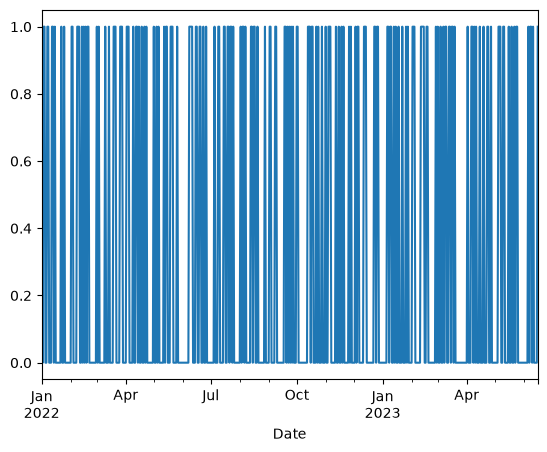

In [5]:
#Checking is promotions are pre-planned
store = "S003"
product = "P0003"
tmp = train_df[(train_df["Store ID"] == store) & (train_df["Product ID"] == product)].groupby("Date")["Promotion"].max()
tmp.plot()
count = (tmp == 0).sum()
print(len(tmp))
print(count)

np.int64(875)

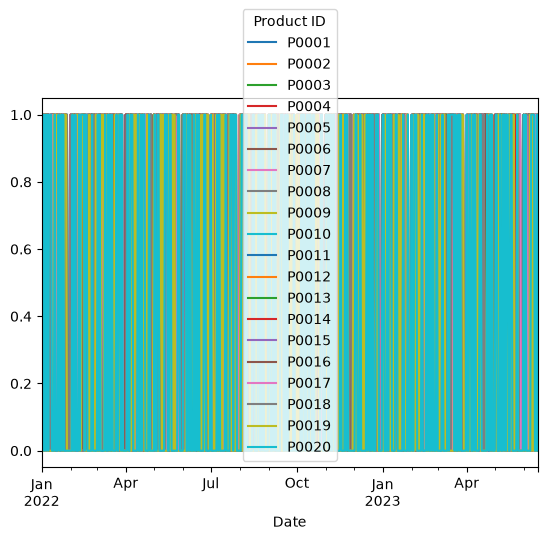

In [6]:
pivot = train_df[
    (train_df["Store ID"] == "S002")
].pivot_table(
    index="Date",
    columns="Product ID",
    values="Promotion",
    aggfunc="max"
)
pivot.plot()

train_df[train_df["Product ID"] == "P0003"]["Promotion"].sum()

# A given product is promoted in all stores at once and and the total number of times a 
# product was promoted is approximately the same for all products.
# But there is no clear monthly or yearly pattern for promotion so it will be considered unkown with only a year's data
# Weather can also be considered known because of weather forecasts well before prediction time


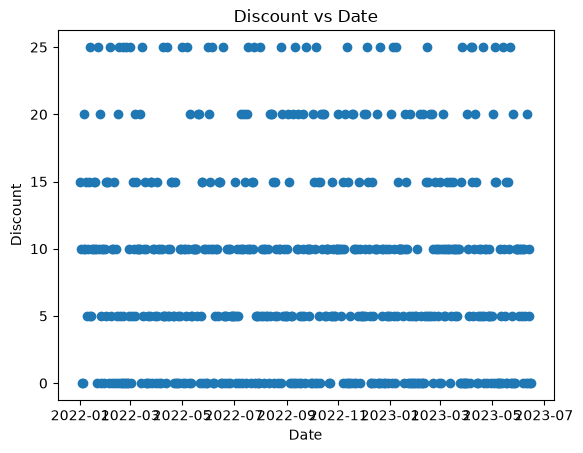

In [7]:
train_df[train_df["Product ID"] == "P0004"]["Discount"].unique()
#same few discounts for all products
#for a given discount not all products have the same number of purchases but the numbers are close

store = "S001"
product = "P0002"

tmp = train_df[
    (train_df["Store ID"] == store) &
    (train_df["Product ID"] == product)
].sort_values("Date")

plt.scatter(tmp["Date"], tmp["Discount"])
plt.title("Discount vs Date")
plt.xlabel("Date")
plt.ylabel("Discount")
plt.show()

#There is no particular pattern in the discounts given out

FEATURE CLASSIFICATION

Static features

For a given Store ID and Product ID pair, the following features are static:
Store ID
Product ID
Category
Region

Past known features

Observed:
Inventory Level
Units Sold
Units Ordered
Demand

Exogenous:
Price
Discount
Competitor Pricing
Weather Condition
Promotion
Epidemic
Seasonality

Future known

Date
Day of week
Month
Week
Quarter
Is weekend
Is month start/end
Season (if rule-based)
Holiday flags (if external calendar added)
Weather Condition (Forecast)

Future unknown

Demand
Units Sold
Inventory Level
Epidemic
Competitor Pricing
Price (assuming prices can change)
Discount
Units Ordered
Promotion

Target Features

Demand
Units Sold
Inventory level

Decision variables

Price
Discount
Promotion
Units Ordered